In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv("/content/drive/MyDrive/spaceship-titanic - Copy/ev_battery_qc_data_2026_kaggle.csv")
df.head()

,Cell_ID,Batch_ID,Production_Line,Shift,Supplier,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type,Inspector_Comment,QC_Grade
0,CELL-004920,BTH-0001,Line_3,Evening,ChemCorp,20.76,0.108,14.81,14.01,4980.0,97.79,Poor Retention,NaN,Scrap
1,CELL-014782,BTH-0001,Line_1,Night,ChemCorp,22.38,0.126,14.96,14.70,4989.0,97.35,NaN,NaN,Grade A
2,CELL-019348,BTH-0001,Line_2,Night,LithioMat,20.18,0.135,14.97,13.80,5032.0,96.77,NaN,Routine visual inspection passed.,Grade A
3,CELL-008537,BTH-0001,Line_2,Morning,VoltIndustries,24.30,0.162,14.84,14.65,5042.0,95.88,NaN,NaN,Grade A
4,CELL-010539,BTH-0001,Line_1,Evening,VoltIndustries,22.22,0.130,14.89,15.04,4943.0,97.74,High Internal Resistance,NaN,Grade A


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Cell_ID                   20000 non-null  object 
 1   Batch_ID                  20000 non-null  object 
 2   Production_Line           20000 non-null  object 
 3   Shift                     20000 non-null  object 
 4   Supplier                  20000 non-null  object 
 5   Ambient_Temp_C            19400 non-null  float64
 6   Anode_Overhang_mm         20000 non-null  float64
 7   Electrolyte_Volume_ml     20000 non-null  float64
 8   Internal_Resistance_mOhm  20000 non-null  float64
 9   Capacity_mAh              20000 non-null  float64
 10  Retention_50Cycle_Pct     20000 non-null  float64
 11  Defect_Type               3501 non-null   object 
 12  Inspector_Comment         1667 non-null   object 
 13  QC_Grade                  20000 non-null  object 
dtypes: flo

,0
Cell_ID,0
Batch_ID,0
Production_Line,0
Shift,0
Supplier,0
Ambient_Temp_C,600
Anode_Overhang_mm,0
Electrolyte_Volume_ml,0
Internal_Resistance_mOhm,0
Capacity_mAh,0


In [5]:
df = df.drop(columns=["Defect_Type"])

In [7]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [8]:
df.dtypes

,0
Cell_ID,object
Batch_ID,object
Production_Line,object
Shift,object
Supplier,object
Ambient_Temp_C,float64
Anode_Overhang_mm,float64
Electrolyte_Volume_ml,float64
Internal_Resistance_mOhm,float64
Capacity_mAh,float64


In [9]:
df = df.drop(columns=["Cell_ID","Batch_ID"])

In [10]:
df = df.drop(columns=["Inspector_Comment"])

In [11]:
from sklearn.preprocessing import LabelEncoder
le  = LabelEncoder()

df["Production_Line"] = le.fit_transform(df["Production_Line"])
df["Shift"] = le.fit_transform(df["Shift"])
df["Supplier"] = le.fit_transform(df["Supplier"])
df["QC_Grade"] = le.fit_transform(df["QC_Grade"])


In [12]:
df.dtypes

,0
Production_Line,int64
Shift,int64
Supplier,int64
Ambient_Temp_C,float64
Anode_Overhang_mm,float64
Electrolyte_Volume_ml,float64
Internal_Resistance_mOhm,float64
Capacity_mAh,float64
Retention_50Cycle_Pct,float64
QC_Grade,int64


In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = df.drop("QC_Grade",axis=1)
y = df["QC_Grade"]
X_scaled = scaler.fit_transform(X)


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [19]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

In [20]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [22]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_test,y_pred))

print(classification_report(y_test,y_pred))

[[2611    0    0]
 [   0  760    0]
 [   0    0  629]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2611
           1       1.00      1.00      1.00       760
           2       1.00      1.00      1.00       629

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [23]:
feature_importance = model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)


                    Feature  Importance
4         Anode_Overhang_mm    0.752774
6  Internal_Resistance_mOhm    0.158244
7              Capacity_mAh    0.045871
8     Retention_50Cycle_Pct    0.022608
5     Electrolyte_Volume_ml    0.012480
3            Ambient_Temp_C    0.004082
2                  Supplier    0.002758
0           Production_Line    0.000666
1                     Shift    0.000518


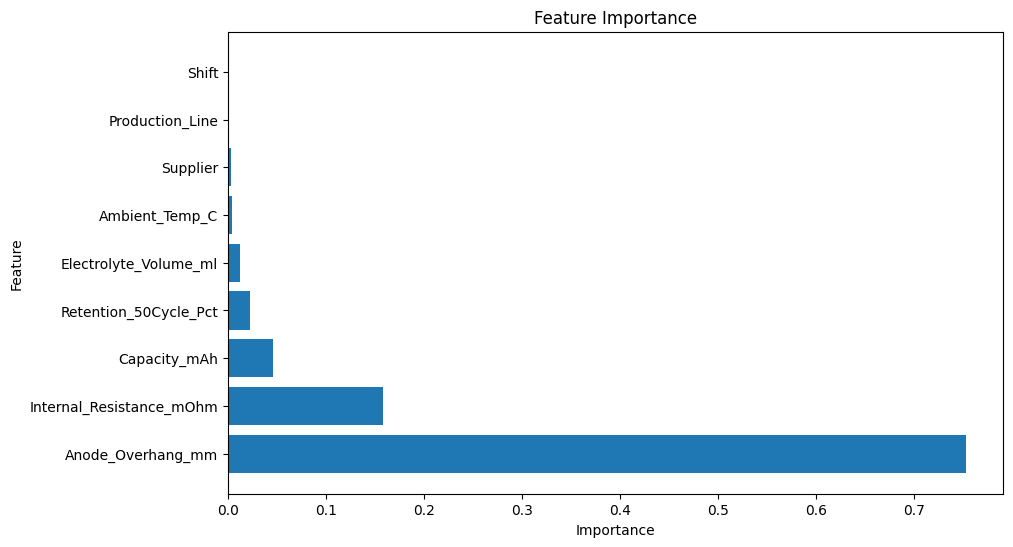

In [24]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()


EDA(Exploratory Data Analysis)

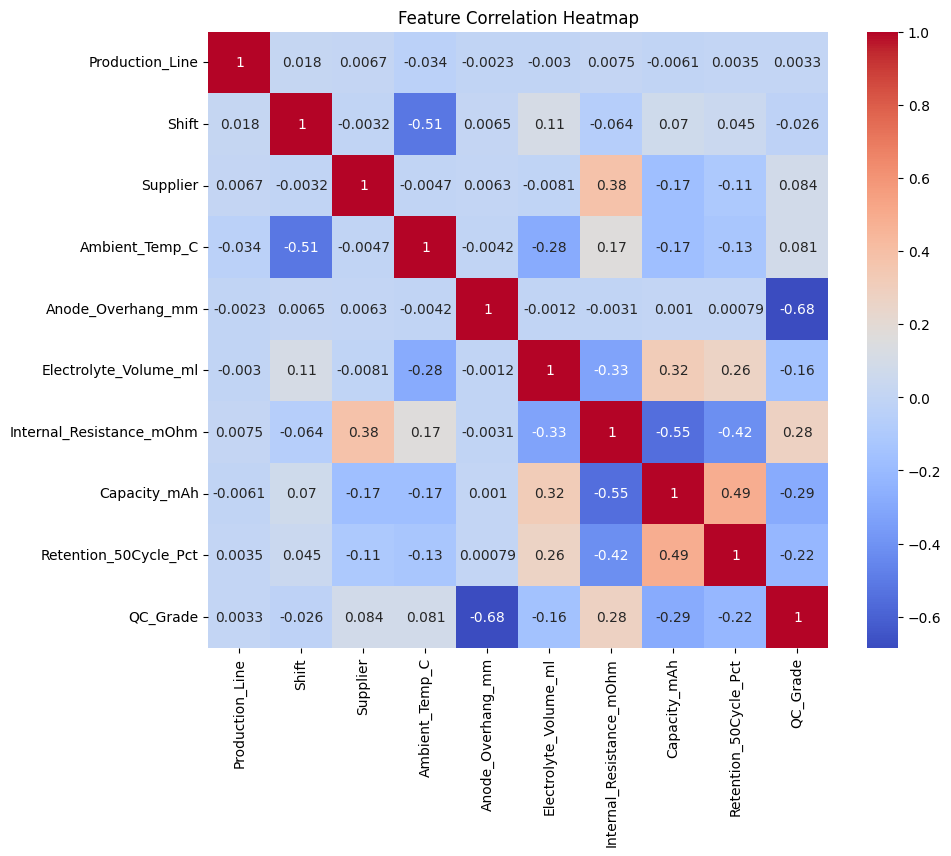

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

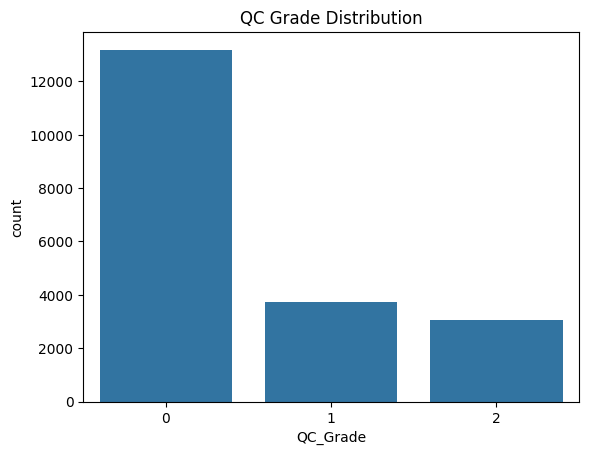

In [26]:
sns.countplot(x='QC_Grade',data=df)
plt.title('QC Grade Distribution')
plt.show()

Model Comparison

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [28]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, accuracy_score(y_test, pred))

Logistic Regression 0.86425
Decision Tree 0.99975
Random Forest 1.0


In [29]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_scaled, y, cv=5)

print("Cross Validation Score:", scores.mean())

Cross Validation Score: 1.0


In [30]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100,200],
    "max_depth": [5,10,None]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 5, 'n_estimators': 100}


In [31]:
import pickle

pickle.dump(model,open('ev_battery_model.pkl','wb'))

In [32]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 45.8 MB/s eta 0:00:00


In [33]:
!pip  install streamlit pyngrok

In [41]:
%%writefile app.py

import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("ev_battery_model.pkl","rb"))

st.title("EV Battery Quality Prediction")

Ambient_Temp_C = st.number_input("Ambient Temperature")
Anode_Overhang_mm = st.number_input("Anode Overhang")
Electrolyte_Volume_ml = st.number_input("Electrolyte Volume")
Internal_Resistance_mOhm = st.number_input("Internal Resistance")
Capacity_mAh = st.number_input("Capacity")
Retention_50Cycle_Pct = st.number_input("Retention")

Production_Line = st.number_input("Production Line")
Shift = st.number_input("Shift")
Supplier = st.number_input("Supplier")

if st.button("Predict"):

    features = np.array([[Ambient_Temp_C,
                          Anode_Overhang_mm,
                          Electrolyte_Volume_ml,
                          Internal_Resistance_mOhm,
                          Capacity_mAh,
                          Retention_50Cycle_Pct,
                          Production_Line,
                          Shift,
                          Supplier]])

    prediction = model.predict(features)

    grade_map = {
    0: "Grade A",
    1: "Grade B",
    2: "Scrap"
}

prediction = model.predict(features)[0]

st.success(f"Predicted QC Grade: {grade_map[prediction]}")



Overwriting app.py


In [42]:
!streamlit run app.py &>/dev/null &

In [43]:
from pyngrok import ngrok

# Replace 'YOUR_NGROK_AUTHTOKEN' with your actual ngrok authtoken
ngrok.set_auth_token("3AiYQI9h2dQLZDDX1CzZ3mBoh3j_47DsmiN2kScH4W7GNbHWy")

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://semitraditional-unmistaken-willie.ngrok-free.dev" -> "http://localhost:8501"
